# Shakespeare Sonnet Generator using LSTM

## Project Overview
This project trains a neural language model to generate Shakespeare-style text using a dataset of sonnets. 
The model learns word sequences and predicts the next word using an LSTM-based neural network.

## Pipeline
1. Load and explore dataset
2. Text preprocessing and vectorization
3. Generate n-gram sequences
4. Pad sequences
5. Create features and labels
6. Build and train LSTM model
7. Evaluate model performance
8. Generate new text

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle

In [2]:
with open('sonnets.txt') as f:
    data = f.read()

corpus = data.lower().split("\n")

print(f"There are {len(corpus)} lines of sonnets\n")
print(f"The first 5 lines look like this:\n")
for i in range(5):
  print(corpus[i])

There are 2159 lines of sonnets

The first 5 lines look like this:

from fairest creatures we desire increase,
that thereby beauty's rose might never die,
but as the riper should by time decease,
his tender heir might bear his memory:
but thou, contracted to thine own bright eyes,


## Text Vectorization

We convert text into numerical representations using TensorFlow's 
TextVectorization layer. This step builds a vocabulary and maps words to integers.

In [3]:
def fit_vectorizer(corpus):    
    tf.keras.utils.set_random_seed(65)

    vectorizer = tf.keras.layers.TextVectorization(ragged=True)
    
    vectorizer.adapt(corpus)
    
    return vectorizer

In [5]:
vectorizer = fit_vectorizer(corpus)
total_words = len(vectorizer.get_vocabulary())
print(f"Total number of words in corpus: {total_words}")

Total number of words in corpus: 3189


In [6]:
def n_gram_seqs(corpus, vectorizer):
    input_sequences = []

    for line in corpus:
        sequence = vectorizer(line)

        for i in range(1, len(sequence)):
            n_gram_sequence = sequence[:i+1]
            input_sequences.append(n_gram_sequence)

    
    return input_sequences

In [7]:
# Test your function with one example
first_example_sequence = n_gram_seqs([corpus[0]], vectorizer)

print("n_gram sequences for first example look like this:\n")
first_example_sequence

n_gram sequences for first example look like this:



[<tf.Tensor: shape=(2,), dtype=int64, numpy=array([ 35, 489])>,
 <tf.Tensor: shape=(3,), dtype=int64, numpy=array([  35,  489, 1259])>,
 <tf.Tensor: shape=(4,), dtype=int64, numpy=array([  35,  489, 1259,  164])>,
 <tf.Tensor: shape=(5,), dtype=int64, numpy=array([  35,  489, 1259,  164,  230])>,
 <tf.Tensor: shape=(6,), dtype=int64, numpy=array([  35,  489, 1259,  164,  230,  582])>]

In [8]:
# Test your function with a bigger corpus
next_3_examples_sequence = n_gram_seqs(corpus[1:4], vectorizer)

print("n_gram sequences for next 3 examples look like this:\n")
next_3_examples_sequence

n_gram sequences for next 3 examples look like this:



[<tf.Tensor: shape=(2,), dtype=int64, numpy=array([  9, 935])>,
 <tf.Tensor: shape=(3,), dtype=int64, numpy=array([  9, 935, 143])>,
 <tf.Tensor: shape=(4,), dtype=int64, numpy=array([  9, 935, 143, 369])>,
 <tf.Tensor: shape=(5,), dtype=int64, numpy=array([  9, 935, 143, 369, 101])>,
 <tf.Tensor: shape=(6,), dtype=int64, numpy=array([  9, 935, 143, 369, 101, 171])>,
 <tf.Tensor: shape=(7,), dtype=int64, numpy=array([  9, 935, 143, 369, 101, 171, 207])>,
 <tf.Tensor: shape=(2,), dtype=int64, numpy=array([17, 23])>,
 <tf.Tensor: shape=(3,), dtype=int64, numpy=array([17, 23,  3])>,
 <tf.Tensor: shape=(4,), dtype=int64, numpy=array([  17,   23,    3, 1006])>,
 <tf.Tensor: shape=(5,), dtype=int64, numpy=array([  17,   23,    3, 1006,   64])>,
 <tf.Tensor: shape=(6,), dtype=int64, numpy=array([  17,   23,    3, 1006,   64,   31])>,
 <tf.Tensor: shape=(7,), dtype=int64, numpy=array([  17,   23,    3, 1006,   64,   31,   51])>,
 <tf.Tensor: shape=(8,), dtype=int64, numpy=array([  17,   23,   

In [9]:
# Apply the n_gram_seqs transformation to the whole corpus
input_sequences = n_gram_seqs(corpus, vectorizer)

# Save max length 
max_sequence_len = max([len(x) for x in input_sequences])

print(f"n_grams of input_sequences have length: {len(input_sequences)}")
print(f"maximum length of sequences is: {max_sequence_len}")

n_grams of input_sequences have length: 15355
maximum length of sequences is: 11


## Padding Sequences

Since sequences have different lengths, we pad them to the same size 
so they can be processed by the neural network.

In [10]:
def pad_seqs(input_sequences, max_sequence_len):
    padded_sequences = np.array(tf.keras.utils.pad_sequences(input_sequences,maxlen=max_sequence_len,padding='pre'))

    return padded_sequences

In [11]:
# Pad the whole corpus
input_sequences = pad_seqs(input_sequences, max_sequence_len)

print(f"padded corpus has shape: {input_sequences.shape}")

padded corpus has shape: (15355, 11)


In [12]:
# Test your function with the n_grams_seq of the first example
first_padded_seq = pad_seqs(first_example_sequence, max([len(x) for x in first_example_sequence]))
first_padded_seq

array([[   0,    0,    0,    0,   35,  489],
       [   0,    0,    0,   35,  489, 1259],
       [   0,    0,   35,  489, 1259,  164],
       [   0,   35,  489, 1259,  164,  230],
       [  35,  489, 1259,  164,  230,  582]], dtype=int32)

In [13]:
# Test your function with the n_grams_seq of the next 3 examples
next_3_padded_seq = pad_seqs(next_3_examples_sequence, max([len(s) for s in next_3_examples_sequence]))
next_3_padded_seq

array([[   0,    0,    0,    0,    0,    0,    9,  935],
       [   0,    0,    0,    0,    0,    9,  935,  143],
       [   0,    0,    0,    0,    9,  935,  143,  369],
       [   0,    0,    0,    9,  935,  143,  369,  101],
       [   0,    0,    9,  935,  143,  369,  101,  171],
       [   0,    9,  935,  143,  369,  101,  171,  207],
       [   0,    0,    0,    0,    0,    0,   17,   23],
       [   0,    0,    0,    0,    0,   17,   23,    3],
       [   0,    0,    0,    0,   17,   23,    3, 1006],
       [   0,    0,    0,   17,   23,    3, 1006,   64],
       [   0,    0,   17,   23,    3, 1006,   64,   31],
       [   0,   17,   23,    3, 1006,   64,   31,   51],
       [  17,   23,    3, 1006,   64,   31,   51,  803],
       [   0,    0,    0,    0,    0,    0,   27,  315],
       [   0,    0,    0,    0,    0,   27,  315,  745],
       [   0,    0,    0,    0,   27,  315,  745,  101],
       [   0,    0,    0,   27,  315,  745,  101,  209],
       [   0,    0,   27,  315,

## 6. Create Training Dataset

Each sequence is split into:

Features: all words except the last  
Label: the next word the model should predict

In [14]:
NUM_BATCHES = 16
def features_and_labels_dataset(input_sequences, total_words):
    
    features = []
    labels = []

    for seq in input_sequences:
        if len(seq) > 1:
            features.append(seq[:-1])
            labels.append(seq[-1])

    one_hot_labels = tf.keras.utils.to_categorical(labels,num_classes=total_words)

    dataset = tf.data.Dataset.from_tensor_slices((features,one_hot_labels)) 

    batched_dataset = dataset.batch(16)

    return batched_dataset

In [15]:
dataset_example = features_and_labels_dataset(first_padded_seq, total_words)

print("Example:\n")
for features, label in dataset_example.take(1):
    print(f"N grams:\n\n {features}\n")
    print(f"Label shape:\n\n {label.shape}")

Example:

N grams:

 [[   0    0    0    0   35]
 [   0    0    0   35  489]
 [   0    0   35  489 1259]
 [   0   35  489 1259  164]
 [  35  489 1259  164  230]]

Label shape:

 (5, 3189)


In [16]:
dataset = features_and_labels_dataset(input_sequences, total_words).prefetch(tf.data.AUTOTUNE)

print(f"Feature shape: {dataset.element_spec[0]}")
print(f"Label shape: {dataset.element_spec[1]}")

Feature shape: TensorSpec(shape=(None, 10), dtype=tf.int32, name=None)
Label shape: TensorSpec(shape=(None, 3189), dtype=tf.float64, name=None)


## 7. LSTM Language Model

We use an LSTM network because it is effective at learning 
sequential patterns in text data.

Architecture:
Embedding → LSTM → Dense → Softmax

In [21]:
LSTM_UNITS = 128

def create_model(total_words, max_sequence_len):
    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Input(shape = (max_sequence_len-1,)))
    model.add(tf.keras.layers.Embedding(total_words, 100))
    model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(LSTM_UNITS)))
    model.add(tf.keras.layers.Dense(total_words,activation='softmax'))

    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics = ['accuracy'])

    return model

In [22]:
model = create_model(total_words, max_sequence_len)


In [23]:
example_batch = dataset.take(1)

model.evaluate(example_batch, verbose=False)
predictions = model.predict(example_batch, verbose=False)
print(f"predictions have shape: {predictions.shape}")

predictions have shape: (16, 3189)


In [24]:
history = model.fit(dataset, epochs=30, verbose=1)

Epoch 1/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.0274 - loss: 6.8718
Epoch 2/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.0346 - loss: 6.1423
Epoch 3/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.0430 - loss: 5.6949
Epoch 4/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.0540 - loss: 5.3677
Epoch 5/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.0600 - loss: 5.1322
Epoch 6/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.0749 - loss: 4.9507
Epoch 7/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.0908 - loss: 4.6940
Epoch 8/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.1278 - loss: 4.3659
Epoch 9/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.1719 - loss: 4.0657
Epoch 10/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.2169 - loss: 3.7910
Epoch 11/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.2562 - loss: 3.6054
Epoch 12/30
960/960 ━━━━━━━━━━

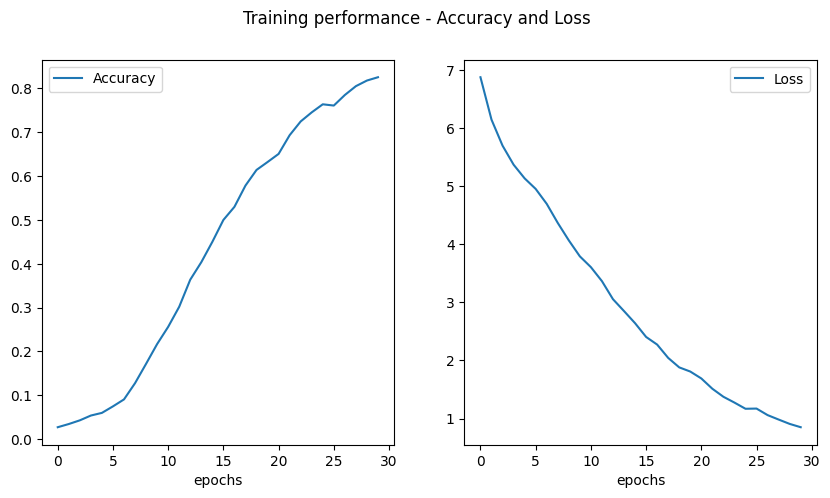

In [25]:
acc = history.history['accuracy']
loss = history.history['loss']

epochs = range(len(acc))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Training performance - Accuracy and Loss')

for i, (data, label) in enumerate(zip([acc,loss], ["Accuracy", "Loss"])):
    ax[i].plot(epochs, data, label=label)
    ax[i].legend()
    ax[i].set_xlabel('epochs')

In [26]:
seed_text = "Help me Obi Wan Kenobi, you're my only hope"
next_words = 100
  
for _ in range(next_words):
    token_list = vectorizer(seed_text)
    token_list = tf.keras.utils.pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model.predict([token_list], verbose=0)
    predicted = np.argmax(predicted, axis=-1).item()
    output_word = vectorizer.get_vocabulary()[predicted]
    seed_text += " " + output_word

print(seed_text)

/opt/homebrew/Cellar/jupyterlab/4.3.5_1/libexec/lib/python3.13/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_7
Received: inputs=('Tensor(shape=(1, 10))',)
  warnings.warn(msg)


Help me Obi Wan Kenobi, you're my only hope thee out me more bright so blind patent me doth me bright thine defect thine bright grace thine bright in thine eye is less care to me perpetual hate new hate forsworn to me sight monarchs end you prove so dumb as hell respect offence lie swearing eye the best worlds end may see well to stand eternity eternity me thee to me so true more bright of thee tend to thee more more art filching treasure good note of bitterness joy forged fall darkness catch worms cunning love to me love thee so know grace me so more lies


In [27]:
seed_text = "love is a smoke"

next_words = 100
  
for _ in range(next_words):
    token_list = vectorizer(seed_text)
    token_list = tf.keras.utils.pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model.predict([token_list], verbose=0)
    predicted = np.argmax(predicted, axis=-1).item()
    output_word = vectorizer.get_vocabulary()[predicted]
    seed_text += " " + output_word

print(seed_text)

love is a smoke to his love is tied them hell willing motley willing modern state now his adjunct pride pride loving truth whole wiry spends wretch do not to thee benefit me true love good treasure so oft can i love thee i will come thee forsworn again dearer physicians lie by bitterness of rest groan bail blind unkindness lie doth reason truth thine eye doth youth grow doom lease thrive matter pen doth spend lie so tell the eye of true sight guess lies forgot groan hate lovesuit sweet help and found of rain fire truth knowst bitterness joy prove them more


## Conclusion

This project demonstrates how LSTM networks can learn language patterns
and generate Shakespeare-style text. The model learns word sequences
and predicts the next word iteratively to generate poetry-like sentences.